# TP2 — Detector de máximo enfoque en el dominio espectral

![](consigna.png)

171 frames de 640x360 a 29.97 fps


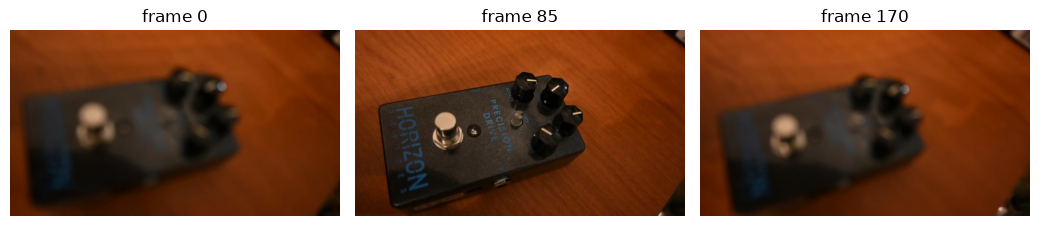

In [26]:
%matplotlib inline
from typing import NamedTuple
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from focus_utils import read_frames, show, spectrum, hann, gaussian_blur

VIDEO_PATH = "focus_video.mov"

frames, fps = read_frames(VIDEO_PATH)                                  # (N, H, W, 3) BGR
gray = np.stack([cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames])   # (N, H, W)
shape = gray.shape[1:]

print(f"{len(frames)} frames de {shape[1]}x{shape[0]} a {fps:.2f} fps")
show(frames[[0, len(frames) // 2, -1]], ["frame 0", f"frame {len(frames) // 2}", f"frame {len(frames) - 1}"])

## 1. Métrica *Frequency domain image blur Measure* (FM)

Toma valores entre 0 y 1: cuanto más cercanos a 1, más nítida es la imagen.

Para implementar el algoritmo hay que seguir los pasos de la [sección 3.1 del paper](https://www.researchgate.net/publication/275538598_Image_Sharpness_Measure_for_Blurred_Images_in_Frequency_Domain):
1. Computar $F$, la transformada de Fourier de la imagen $I$ de tamaño $M \times N$.
2. Obtener $F_c$, que es $F$ con el origen desplazado al centro (`fftshift`).
3. Calcular $A_F = |F_c|$, el valor absoluto (módulo) de $F_c$.
4. Calcular $A_{max} = \max(A_F)$, la componente de frecuencia de mayor amplitud. El paper la llama $M$; se renombra para no confundirla con el alto de la imagen.
5. Calcular $T_H$, la cantidad de puntos con $A_F > \text{umbral}$, siendo $\text{umbral} = A_{max}/1000$.
6. Aplicar la ecuación $FM = T_H / (M \times N)$.

**Intuición:** al desenfocar se apagan las rayas finas; menos patrones superan el umbral y FM cae. El umbral es relativo al máximo, así que un cambio de brillo global no altera el conteo. Dividir por el área permite comparar regiones de distinto tamaño.

In [27]:
def fm_sharpness(gray, ratio=1000):
    # Frequency domain image blur Measure (De & Masilamani, 2013).
    img = gray.astype(np.float64)
    af = np.abs(np.fft.fftshift(np.fft.fft2(img)))  # el shift no altera el conteo, se deja por fidelidad al paper
    return np.count_nonzero(af > af.max() / ratio) / img.size

## 2. Regiones y experimentos

Una región es un rectángulo `Rect(x, y, w, h)`. El experimento 1 es simplemente la región frame completo.

Para que la ROI ocupe una fracción $p$ del área sin deformarse, cada lado se escala por $\sqrt{p}$.

In [28]:
class Rect(NamedTuple):
    x: int
    y: int
    w: int
    h: int

    def crop(self, img):
        return img[self.y:self.y + self.h, self.x:self.x + self.w]


def rect_at(shape, cx, cy, rw, rh):
    # Rect centrado en (cx, cy) de tamaño (rw, rh); todo relativo al frame.
    h, w = shape
    rw, rh = round(rw * w), round(rh * h)
    return Rect(round(cx * w - rw / 2), round(cy * h - rh / 2), rw, rh)


def center_roi(shape, area_frac):
    side = np.sqrt(area_frac)
    return rect_at(shape, 0.5, 0.5, side, side)


def fm_curve(gray, rect, metric=fm_sharpness):
    return np.array([metric(rect.crop(g)) for g in gray])


regions = {
    "frame completo": rect_at(shape, 0.5, 0.5, 1, 1),
    "ROI 10%": center_roi(shape, 0.10),
    "ROI 5%": center_roi(shape, 0.05),
}
colors = dict(zip(regions, ["tab:blue", "tab:orange", "tab:green"]))
curves = {name: fm_curve(gray, r) for name, r in regions.items()}
for name, r in regions.items():
    print(f"{name:15s} {r}  área = {r.w * r.h / (shape[0] * shape[1]):.1%}")

frame completo  Rect(x=0, y=0, w=640, h=360)  área = 100.0%
ROI 10%         Rect(x=219, y=123, w=202, h=114)  área = 10.0%
ROI 5%          Rect(x=248, y=140, w=143, h=80)  área = 5.0%


## 3. Detección automática del máximo enfoque

La curva cruda tiene ruido de frame a frame, así que:
1. **Suavizado** con promedio móvil de `k` frames.
2. **Pico** = máximo de la curva suavizada → frame de máximo enfoque.
3. **Zona de máximo enfoque** = tramo contiguo alrededor del pico donde la curva normalizada al rango $[0, 1]$ supera `level` (90 %).

Normalizar al rango hace que el criterio no dependa de la escala absoluta de FM (que cambia mucho entre frame completo y ROI).

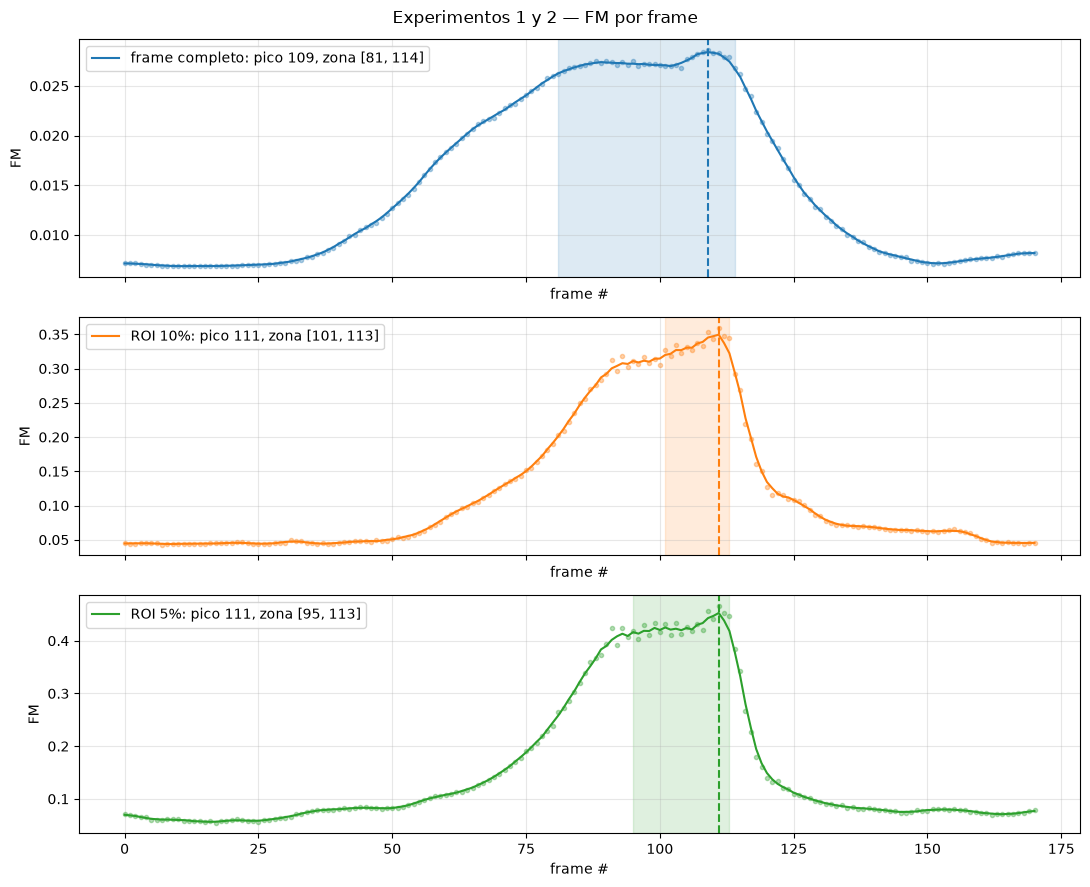

región                  pico        zona   FM min   FM max contraste
frame completo           109   [81, 114]   0.0069   0.0284      4.1x
ROI 10%                  111  [101, 113]   0.0438   0.3496      8.0x
ROI 5%                   111   [95, 113]   0.0565   0.4527      8.0x


In [29]:
class Focus(NamedTuple):
    peak: int
    start: int
    end: int
    smooth: np.ndarray


def moving_average(x, k):
    return np.convolve(np.pad(x, k // 2, mode="edge"), np.ones(k) / k, mode="valid")


def detect_focus(curve, k=5, level=0.9):
    s = moving_average(curve, k)
    n = (s - s.min()) / np.ptp(s)
    peak = start = end = int(n.argmax())
    while start > 0 and n[start - 1] >= level:
        start -= 1
    while end < len(n) - 1 and n[end + 1] >= level:
        end += 1
    return Focus(peak, start, end, s)


def plot_focus(ax, curve, f, label, color):
    ax.plot(curve, ".", color=color, alpha=0.35)
    ax.plot(f.smooth, color=color, label=f"{label}: pico {f.peak}, zona [{f.start}, {f.end}]")
    ax.axvspan(f.start, f.end, color=color, alpha=0.15)
    ax.axvline(f.peak, color=color, ls="--")
    ax.set(xlabel="frame #", ylabel="FM")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def plot_curves(curves, title, colors=colors):
    focus = {name: detect_focus(c) for name, c in curves.items()}
    fig, axs = plt.subplots(len(curves), 1, figsize=(11, 3 * len(curves)), sharex=True)
    for ax, (name, c) in zip(np.atleast_1d(axs), curves.items()):
        plot_focus(ax, c, focus[name], name, colors[name])
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return focus


def summary(curves, focus):
    print(f"{'región':22s} {'pico':>5s} {'zona':>11s} {'FM min':>8s} {'FM max':>8s} {'contraste':>9s}")
    for name, c in curves.items():
        f = focus[name]
        lo, hi = f.smooth.min(), f.smooth.max()
        print(f"{name:22s} {f.peak:5d} {f'[{f.start}, {f.end}]':>11s} {lo:8.4f} {hi:8.4f} {hi / lo:8.1f}x")


focus = plot_curves(curves, "Experimentos 1 y 2 — FM por frame")
summary(curves, focus)

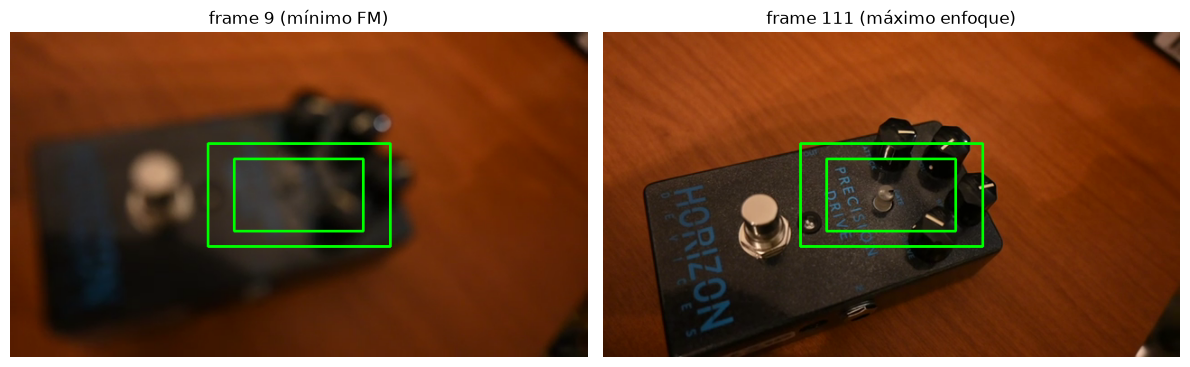

In [30]:
def draw_rects(frame, rects, color, thickness=2):
    out = frame.copy()
    for r in rects:
        cv.rectangle(out, (r.x, r.y), (r.x + r.w, r.y + r.h), color, thickness)
    return out


worst = int(focus["ROI 10%"].smooth.argmin())
best = focus["ROI 10%"].peak
rois = [regions["ROI 10%"], regions["ROI 5%"]]
show([draw_rects(frames[i], rois, (0, 255, 0)) for i in (worst, best)],
     [f"frame {worst} (mínimo FM)", f"frame {best} (máximo enfoque)"], size=6)

### Análisis de los experimentos 1 y 2

Con el frame completo, la curva sube de a poco y forma una meseta ancha. La zona detectada va del frame 81 al 114, con el pico en el 109. La diferencia entre el valor máximo y el mínimo es baja: el máximo es apenas 4 veces el mínimo. Por un lado, el frame incluye el fondo y los bordes de la escena, que están a distintas distancias de la cámara y se enfocan en momentos diferentes. Todo eso se mezcla en un solo número y aplana la curva. Por otro lado, gran parte de la imagen es madera o carcasa lisa, sin detalle que medir, y eso diluye la métrica: FM nunca supera 0.03.

Con la ROI central, en cambio, el resultado es mucho más claro. Las dos versiones, del 10 % y del 5 %, ubican el pico en el frame 111, y la diferencia entre máximo y mínimo se multiplica por 8. La ROI mira solo el centro del pedal, donde están el texto PRECISION DRIVE y las perillas: es una zona con mucho detalle y prácticamente a una sola distancia de la cámara. También se ve que, pasado el frame 113, la curva cae de golpe: el foco pasa por el objeto y lo deja atrás en pocos frames.

Entre las dos ROIs casi no hay diferencias: coinciden en el pico y en el contraste. La del 5 % tiene la mitad de píxeles, así que su curva es un poco más ruidosa y la meseta más plana. Por eso la zona detectada es algo más ancha (frames 95 a 113, contra 101 a 113 con la del 10 %).

En los tres casos, la zona de máximo enfoque cae en el mismo tramo del video, aproximadamente entre los frames 95 y 113. Las imágenes lo confirman: en el frame 111 el texto y las perillas se leen con nitidez.

## 4. Validación

Se toma el frame de máximo enfoque y se lo desenfoca artificialmente con gaussianas de $\sigma$ creciente. Si la métrica está bien implementada, la FM debe caer monótonamente.

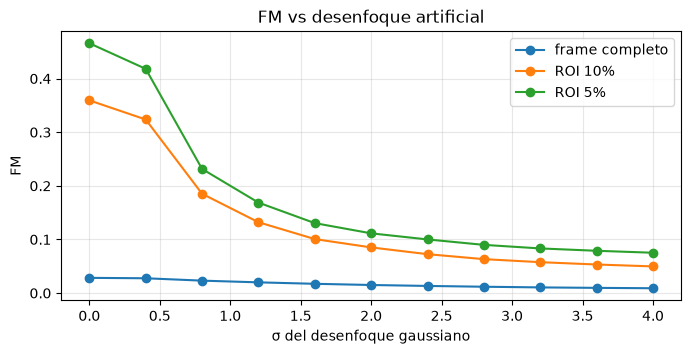

In [31]:
sharp = gray[best]
sigmas = np.arange(0, 4.01, 0.4)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, r in regions.items():
    fm = [fm_sharpness(r.crop(gaussian_blur(sharp, s))) for s in sigmas]
    ax.plot(sigmas, fm, "o-", color=colors[name], label=name)
ax.set(xlabel="σ del desenfoque gaussiano", ylabel="FM", title="FM vs desenfoque artificial")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 5. Ventana de Hann

La FFT asume que la imagen es periódica: las discontinuidades entre bordes opuestos introducen alta frecuencia espuria que forma la cruz del espectro e infla la FM con un piso independiente del enfoque. La ventana de Hann atenúa los bordes hacia cero y lo elimina

`fm_sharpness_hann` aplica la ventana sobre la imagen y luego calcula FM con `fm_sharpness`.

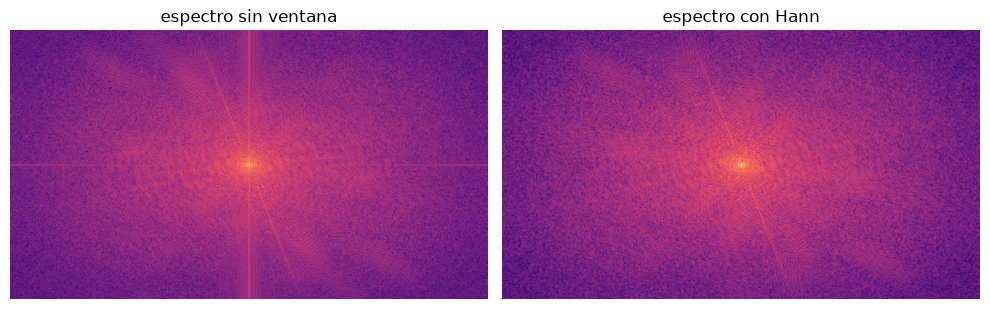

In [32]:
def fm_sharpness_hann(gray, ratio=1000):
    return fm_sharpness(gray * hann(gray.shape), ratio)


g = gray[best].astype(np.float64)
show([spectrum(g), spectrum(g * hann(g.shape))], ["espectro sin ventana", "espectro con Hann"], cmap="magma", size=5)

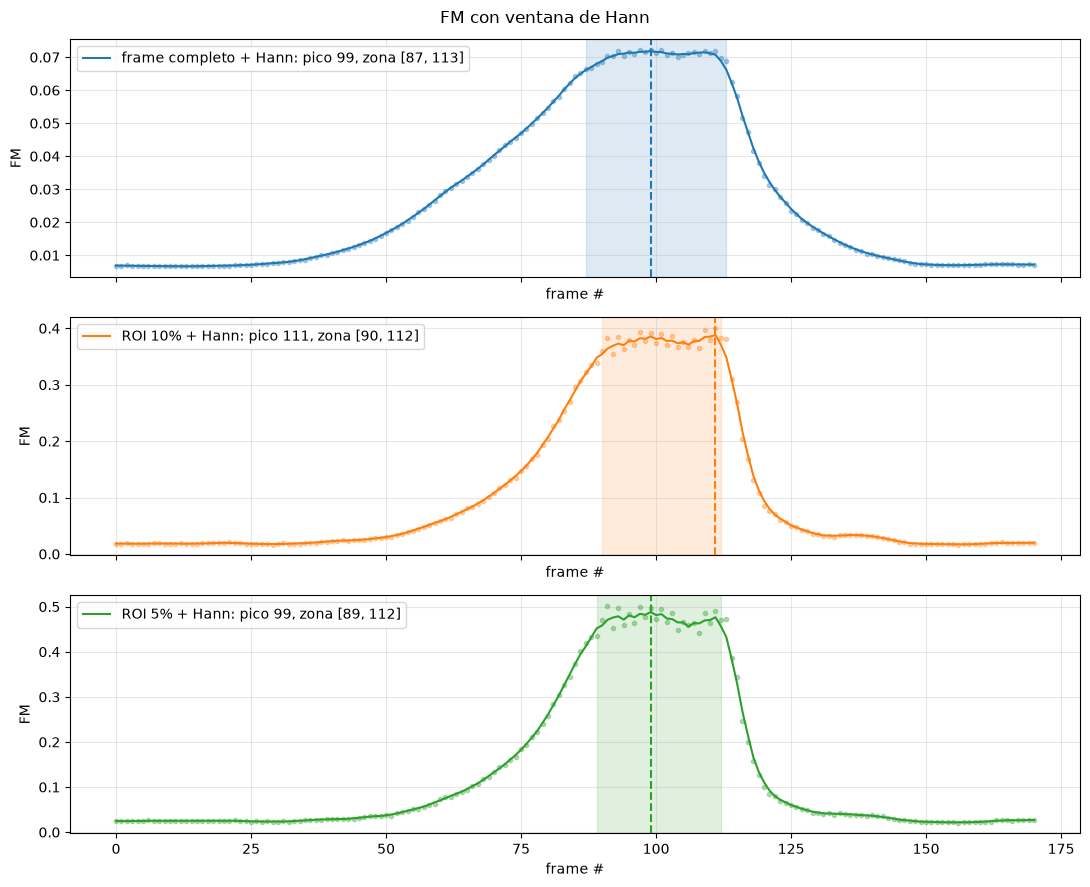

región                  pico        zona   FM min   FM max contraste
frame completo           109   [81, 114]   0.0069   0.0284      4.1x
ROI 10%                  111  [101, 113]   0.0438   0.3496      8.0x
ROI 5%                   111   [95, 113]   0.0565   0.4527      8.0x
frame completo + Hann     99   [87, 113]   0.0067   0.0719     10.8x
ROI 10% + Hann           111   [90, 112]   0.0172   0.3882     22.6x
ROI 5% + Hann             99   [89, 112]   0.0218   0.4881     22.4x


In [33]:
curves_hann = {f"{name} + Hann": fm_curve(gray, r, fm_sharpness_hann) for name, r in regions.items()}
colors_hann = {f"{name} + Hann": c for name, c in colors.items()}
focus_hann = plot_curves(curves_hann, "FM con ventana de Hann", colors_hann)
summary(curves | curves_hann, focus | focus_hann)

### Análisis: con vs sin ventana de Hann

- La ventana baja el piso de la curva en los frames borrosos. En la ROI 10 %, el mínimo pasa de 0.044 a 0.017, porque desaparece el detalle de las costuras. El máximo se mantiene o sube. Como resultado, el contraste casi se triplica (8× → 22×, y 4× → 11× en el frame completo). Es más fácil separar enfocado de desenfocado.
- La meseta de máximo enfoque queda más plana y definida. La zona es [~88, 113] en las tres regiones.
- Dentro de una meseta plana, el `argmax` puede caer en cualquier punto (99 o 111), porque las diferencias son del orden del ruido. El resultado robusto del detector es la zona, no un único frame. Si hace falta un solo frame, conviene tomar el centro de la zona o el pico de la ROI.

## 6. Matriz de enfoque

La idea es imitar el autofoco de una cámara: en lugar de una sola ROI, se reparte una grilla de $7 \times 7$ ROIs chicas sobre el centro del frame, y cada celda tiene su propia curva FM.

Promediando las 49 curvas se obtiene una curva global, que sirve para detectar el frame de máximo enfoque igual que antes. Pero la grilla además permite ver *qué parte* de la escena está nítida en cada momento: si la escena tiene profundidad, cada celda alcanza su máximo en un frame distinto, a medida que el foco la recorre.

Primero se compara el mapa de "mejor frame" de cada celda calculado sin y con la ventana de Hann (sección 5). Después, sobre el frame de máximo enfoque, se pintan de verde las celdas que están al menos al 90 % de su propio máximo, y de rojo las que no.

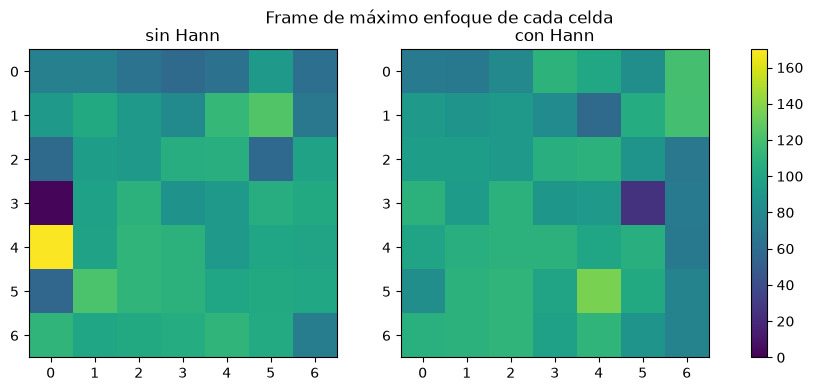

In [34]:
def grid_rects(shape, n=7, span=0.5, fill=0.6):
    # n x n celdas repartidas sobre la fracción `span` central; cada una ocupa `fill` de su paso.
    pitch = span / n
    centers = 0.5 - span / 2 + pitch * (np.arange(n) + 0.5)
    return [rect_at(shape, cx, cy, pitch * fill, pitch * fill) for cy in centers for cx in centers]


N_GRID = 7
grid = grid_rects(shape, N_GRID)
metrics = {"sin Hann": fm_sharpness, "con Hann": fm_sharpness_hann}
G = {name: np.stack([fm_curve(gray, r, m) for r in grid], axis=1) for name, m in metrics.items()}  # (frames, celdas)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, g) in zip(axs, G.items()):
    im = ax.imshow(g.argmax(axis=0).reshape(N_GRID, N_GRID), cmap="viridis", vmin=0, vmax=len(gray) - 1)
    ax.set_title(name)
fig.suptitle("Frame de máximo enfoque de cada celda")
fig.colorbar(im, ax=axs)
plt.show()

**¿Por qué los mapas son tan distintos?**

Sin la ventana aparecen celdas con resultados absurdos. Hay una, por ejemplo, cuyo "mejor" frame es el 3, que está totalmente desenfocado. Esa celda cae sobre la tapa metálica del pulsador. En el frame 3 la atraviesa un degradé borroso, y como la FFT trata a la celda como si se repitiera en mosaico, ese degradé produce saltos fuertes en los bordes. El resultado es FM = 0.99, el valor más alto posible, para una imagen borrosa. En el frame 99, en cambio, la celda es metal liso (con un desvío de apenas 2.2) y da FM = 0.05.

El problema es el tamaño: en una celda de 27×15 píxeles el borde ocupa una parte enorme del total, y el efecto de borde termina dominando la métrica. Con la ventana de Hann el mapa se vuelve mucho más coherente; quedan solo un par de celdas raras, en zonas sin textura. Por eso, de acá en adelante, la matriz se calcula con Hann.

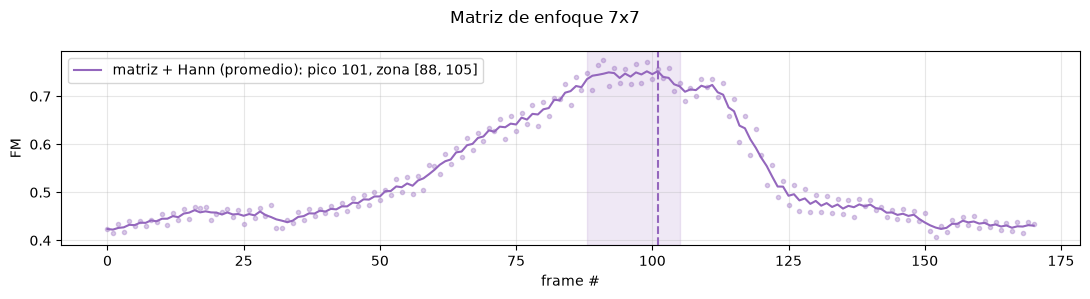

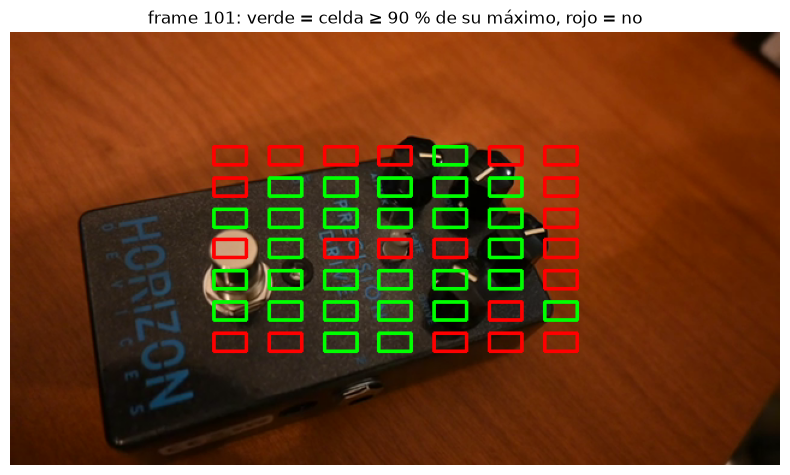

In [35]:
Gw = G["con Hann"]
focus_grid = plot_curves({"matriz + Hann (promedio)": Gw.mean(axis=1)}, "Matriz de enfoque 7x7", {"matriz + Hann (promedio)": "tab:purple"})

peak = focus_grid["matriz + Hann (promedio)"].peak
in_focus = Gw[peak] >= 0.9 * Gw.max(axis=0)
overlay = draw_rects(frames[peak], [r for r, ok in zip(grid, in_focus) if ok], (0, 255, 0))
overlay = draw_rects(overlay, [r for r, ok in zip(grid, in_focus) if not ok], (0, 0, 255))
show([overlay], [f"frame {peak}: verde = celda ≥ 90 % de su máximo, rojo = no"], size=8)

**Análisis de la matriz de enfoque**

La curva promedio va de alrededor de 0.4 a 0.75 y tiene una forma parecida a la de la diapositiva del TP. Detecta la zona de máximo enfoque entre los frames 88 y 105, con el pico en el 101, lo que coincide bastante con lo que se vio con las ROIs.

Lo más interesante es el mapa con Hann, porque deja ver la profundidad de la escena. El centro del pedal llega a su máximo entre los frames 100 y 115, mientras que la fila de arriba y la columna derecha lo alcanzan antes, entre el 60 y el 80. Ahí están las perillas, que sobresalen del pedal, y la madera del borde, que quedan a otra distancia de la cámara. Es decir, el foco recorre la escena de adelante hacia atrás (o al revés), y la matriz permite saber qué parte está nítida en cada momento. Es justamente la información que usa una cámara para decidir *dónde* enfocar.

Las celdas que quedan en rojo en el frame de máximo enfoque son, en su mayoría, zonas sin textura (madera, carcasa negra lisa) o partes que están a otra profundidad. En esas zonas la métrica no tiene nada que medir, y una cámara real directamente las descartaría por tener poco contraste.

## 7. Unsharp masking

Como se vio en clase, el unsharp masking se define como $g = (k+1)\,f - k\,f_B$, donde $f_B$ es la imagen suavizada con una gaussiana. Al restarle a la imagen su versión borrosa quedan solo los detalles finos, y al sumarlos de nuevo se los refuerza. Dicho en términos de Fourier: se vuelven a subir las altas frecuencias que el desenfoque había atenuado.

Se aplica el filtro a todos los frames y se recalcula la curva sobre la ROI del 10 % con `fm_sharpness_hann`. Para ver si la zona de enfoque efectivamente se agranda, se toma el umbral que definía esa zona en el video original (el 90 % del rango de la curva con Hann) y se cuentan cuántos frames lo superan antes y después del filtro.

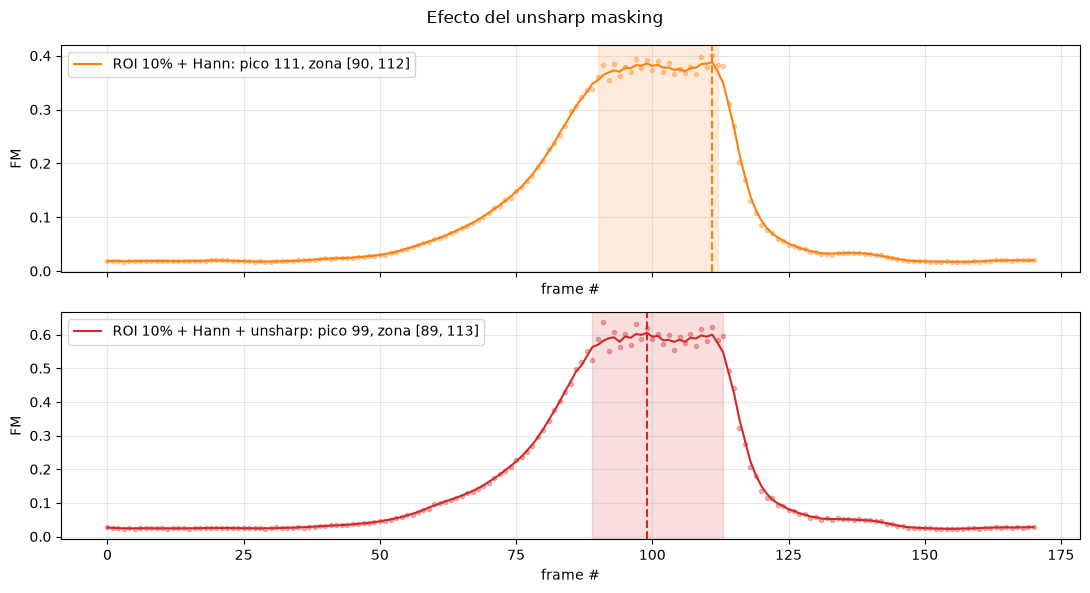

ROI 10% + Hann           :  23 frames sobre FM=0.351  ->  [90, 112]
ROI 10% + Hann + unsharp :  34 frames sobre FM=0.351  ->  [82, 115]


In [36]:
def unsharp_mask(img, k=1.0, sigma=2.0):
    return cv.addWeighted(img, 1 + k, cv.GaussianBlur(img, (0, 0), sigma), -k, 0)


frames_usm = np.stack([unsharp_mask(f) for f in frames])
gray_usm = np.stack([cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames_usm])

roi, ref = regions["ROI 10%"], "ROI 10% + Hann"
pair = {ref: curves_hann[ref], f"{ref} + unsharp": fm_curve(gray_usm, roi, fm_sharpness_hann)}
focus_usm = plot_curves(pair, "Efecto del unsharp masking", {ref: "tab:orange", f"{ref} + unsharp": "tab:red"})

s0 = focus_hann[ref].smooth
threshold = s0.min() + 0.9 * np.ptp(s0)
for name, f in focus_usm.items():
    idx = np.flatnonzero(f.smooth >= threshold)
    print(f"{name:25s}: {idx.size:3d} frames sobre FM={threshold:.3f}  ->  [{idx.min()}, {idx.max()}]")

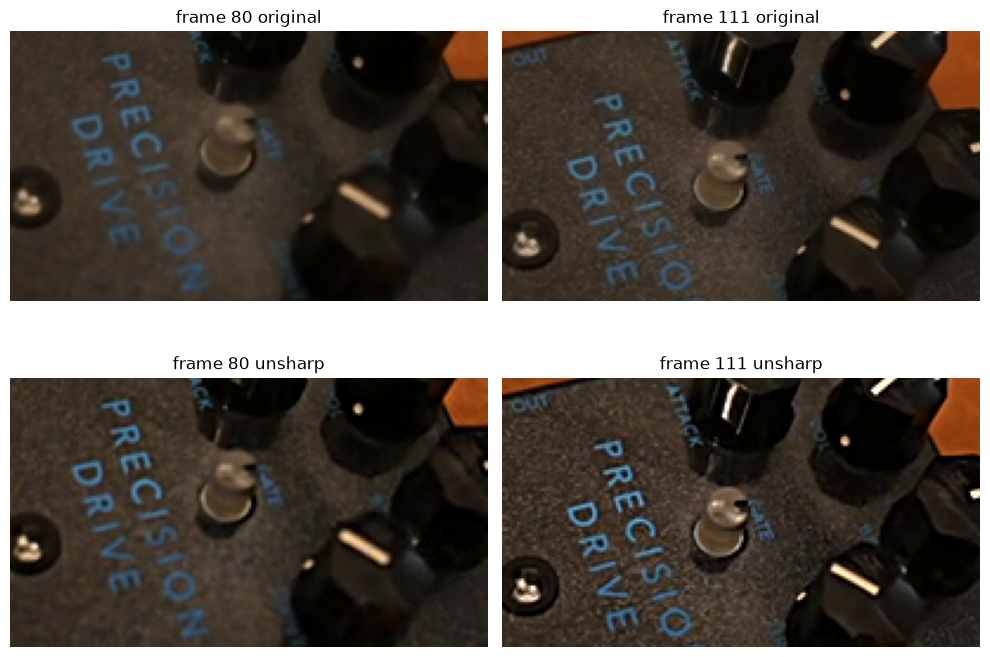

In [37]:
edge = max(focus_hann[ref].start - 10, 0)
show([roi.crop(frames[i]) for i in (edge, best)] + [roi.crop(frames_usm[i]) for i in (edge, best)],
     [f"frame {edge} original", f"frame {best} original", f"frame {edge} unsharp", f"frame {best} unsharp"], cols=2, size=5)

**Análisis del unsharp masking**

Usando el mismo umbral que en el video original, la zona "enfocada" pasa de 23 a 34 frames (de [90, 112] a [82, 115]). O sea, el realce efectivamente agranda la zona de enfoque: los frames que estaban casi enfocados recuperan suficiente detalle como para superar el umbral. A simple vista también se nota: en el frame del borde de la zona, el texto se ve más definido.

Los frames muy desenfocados, en cambio, casi no cambian. El unsharp masking refuerza el detalle que todavía queda en la imagen, pero no puede recuperar el que el desenfoque ya borró.

Igual hay que tomar este resultado con cuidado. FM cuenta cuántas componentes superan un umbral, pero no distingue entre detalle real y ruido. El realce también amplifica el ruido y los artefactos de compresión, y eso sube FM sin que la imagen mejore de verdad. Por eso conviene usar valores moderados de `k` y `sigma` (acá, `k=1` y `sigma=2`).

## 8. Conclusiones

| experimento | pico | zona de máximo enfoque | contraste (máx/mín) |
|---|---|---|---|
| frame completo | 109 | [81, 114] | 4× |
| ROI 10 % | 111 | [101, 113] | 8× |
| ROI 5 % | 111 | [95, 113] | 8× |
| ROI 10 % + Hann | 111 | [90, 112] | 22× |
| matriz 7×7 + Hann | 101 | [88, 105] | 1.8× |

La métrica FM del paper funciona bien como detector de enfoque. Al desenfocar artificialmente un frame, FM baja siempre (sección 4), y todas las variantes coinciden en que el máximo enfoque está aproximadamente entre los frames 90 y 113, con el pico en el 111.

Medir sobre una ROI central da resultados claramente mejores que medir sobre todo el frame. El contraste de la curva se duplica y la zona detectada es más precisa, porque la ROI deja afuera el fondo, que está a otra distancia, y las zonas sin textura.

La ventana de Hann no forma parte del paper, pero mejora mucho la medición: elimina el falso detalle que la FFT genera en los bordes y casi triplica el contraste. En regiones chicas, como las celdas de la matriz de enfoque, es imprescindible; sin ella la métrica directamente da resultados equivocados.

El detector (suavizado, pico y tramo por encima del 90 % del rango) devuelve la zona de máximo enfoque de forma automática. Esa zona es un resultado más confiable que el pico: cuando la curva tiene una meseta, el máximo puede caer en cualquiera de varios frames igual de nítidos.

Por último, FM tiene sus limitaciones. El umbral depende del valor máximo del espectro, que corresponde al brillo promedio, y no del contraste local. Además, el conteo no distingue entre detalle real y ruido. Por eso las regiones lisas, los bordes de la imagen o un realce demasiado agresivo pueden inflar la métrica.